In [ ]:
# Use the list of cities to create site inputs for openeo
# Download sentinel-2 assets based on time, cloudcover and image quality
# Add band math operations
# https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel/sentinel-2/

# two seasons -
# 1: April to June
# 2: Oct to December (default)

# Updated helper files: prepare_openeo.py, utlilities.py
# RTS, May 16 - 20, 2025
# Updated July 28, 2025 to test open mine sites, 200 entries, tab separated
# update the prepare_openeo.py get_sites function

# last used Feb 2026
# single function to collect all assets


In [ ]:
# Setup
from google.colab import drive
import os, sys
drive.mount('/content/drive')
root = '/content/drive/MyDrive/'

# Adjust to your settings
sys.path.append(root +"Colab/research/code/")
datapath = root + "Colab/research/data/"
datapathcities = root + "+Projects/Nudge-X/sites/"
datapathmines = root + "+Projects/Nudge-X/inputdata/"

!pip install openeo --upgrade
!pip install rasterio --upgrade

import openeo
import matplotlib.pyplot as plt
import rasterio

# Available in the GitHub repo Nudge-X
from prepare_openeo import *
from qualcheck_module import *
from utilities import *

In [30]:
# Get the collection of mining sites

# Available in the GitHub repo Nudge-X
collection = "Mines_Metadata_v28.tsv"
file_path = datapathmines + collection
cities, bboxes = get_sites(file_path, "mines", '\t', limit=300)

# Display collection
i = 0;
for site in cities:
    print(i, site)
    i = i+1

0 FimistonOpenPit
1 QuebradaBlancaMine
2 RedLakeMines
3 CrowsNestPass
4 KingsMountainLithiumMine
5 BeauvoirQuarry
6 KalongweDeposit
7 MutshatshaMine
8 KolweziMine
9 TancoMine
10 FooteLithiumMine
11 KoktokayAltayMIne
12 BurangaMine
13 AidyrlaGoldDeposit
14 MirnyMine
15 BishaMine
16 ImourarenUraniumMine
17 HoucaoBauxiteDeposit
18 TsumebMine
19 KoashvaQuarry
20 BuckwheatPit
21 KorshunovskoyeIronDeposit
22 UdachnayaMine
23 PalaboraMine
24 ArgyleDiamondMine
25 SanValentínMine
26 ThompsonMine
27 MaryKathleenMine
28 KhanongOpenPit
29 FilónSurOpenPit
30 ReocínMine
31 LavenderPit
32 ClimaxMine
33 RioTintoBoraxMine
34 LaParrillaMine
35 GirilamboneCopperMine
36 OuenzaMine
37 TincalayuMine
38 SanMiguelOpenPit
39 AmablePit
40 CadiaHillMine
41 BengallaOpenCutMine
42 MangoolaOpenCutMine
43 MountPleasantOpenCutMine
44 GirilamboneCopperMine
45 GibsonsOpenCutMine
46 GlendellOpenCutMine
47 LiddellOpenCutMine
48 MountArthurNorthMine
49 MuswellbrookOpenCutMine
50 RavensworthOpenCutMine
51 SprucePineQuarry


In [32]:
# Select the EO asset
satellite = "SENTINEL2_L1C"

# Set max cloud cover
max_cloud = 5

# Set start and end dates for the search window; consider hemisphere
aprilaugust = True

if(aprilaugust):
    start = "2024-04-01"    #change the start date if you cant find anything in starting November
    end = "2024-09-30"
else:
    start = "2024-09-01"
    end = "2024-12-30"

# Connect to OpenEO through your credentials
connection = openeo.connect(url="openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()


Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [35]:
def process_aspects(
    aspects,
    connection,
    bbox_s,
    city_s,
    start,
    end,
    satellite,
    max_cloud,
    datapathcities,
    small_png=False
):
    """
    Processes multiple Sentinel-2 aspects (e.g., rgb, ndvi, urban_mining)

    Parameters
    ----------
    aspects : List of aspect strings, e.g. ["rgb", "ndvi", "urban_mining"]

    connection : openeo.Connection
    bbox_s : dict
    city_s : str
    start : str
    end : str
    satellite : str
    max_cloud : int
    datapathcities : str
    """

    import matplotlib.pyplot as plt

    for aspect in aspects:

        print("\nProcessing:", aspect)

        # --- Original band selection logic ---
        if(aspect == "rgb"):
            band_selection = ["B02", "B03", "B04"]

        elif(aspect == "ndvi"):
            band_selection = ["B04", "B08"]

        elif(aspect == "urban_mining"):
            band_selection = [
                "B02","B03","B04","B05","B06",
                "B07","B08","B8A","B11","B12"
            ]

        else:
            raise ValueError(f"Unsupported aspect: {aspect}")

        job_title = city_s + "_" + aspect

        # --- Create and execute job ---
        job = create_job_type(
            connection,
            bbox_s,
            start,
            end,
            satellite,
            band_selection,
            max_cloud,
            job_title,
            aspect
        )

        job.start_and_wait()

        # --- Retrieve results ---
        results = job.get_results()
        metadata = results.get_metadata()

        compiled = recompile(metadata)
        res = filter(compiled)

        assets = results.get_assets()
        relevant = [a for a in assets if a.name in res]

        if not relevant:
            print("No valid results for", aspect)
            continue

        latest_result = relevant[-1]

        # --- Download GeoTIFF ---
        date = latest_result.name.split("openEO_")[1]
        date = date.split("Z.tif")[0] + ".tif"

        target = city_s + "_" + aspect + "_" + date
        tif_path = datapathcities + target
        png_path = tif_path.replace(".tif", ".png")

        latest_result.download(tif_path)
        print("Saved:", tif_path)

        # --- Visualization parameters ---
        stretch_contrast = True

        if(aspect == "rgb"):
            brightness_factor = 1.0
            saturation_factor = 0.9
        else:
            brightness_factor = 1.0
            saturation_factor = 1.0

        corrected = adjust_coloration(
            tif_path,
            aspect,
            stretch_contrast,
            brightness_factor,
            saturation_factor
        )

        # ===============================
        # 1) DISPLAY IN NOTEBOOK
        # ===============================
        plt.figure(figsize=(6,6))
        if(aspect == "rgb"):
            plt.imshow(corrected, vmin=-1, vmax=1)
        else:
            plt.imshow(corrected, vmin=-1, vmax=1, cmap='gray')
        plt.axis("off")
        plt.show()

        # ===============================
        # 2) SAVE PNG (SIZE CONTROLLED)
        # ===============================

        if small_png:
            fig_size = 5      # smaller figure
            dpi = 150
            compress = 9      # max PNG compression
        else:
            fig_size = 10
            dpi = 300
            compress = 3

        fig = plt.figure(frameon=False)
        fig.set_size_inches(fig_size, fig_size)

        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)

        if(aspect == "rgb"):
            ax.imshow(corrected, vmin=-1, vmax=1)
        else:
            ax.imshow(corrected, vmin=-1, vmax=1, cmap='gray')

        fig.savefig(
            png_path,
            dpi=dpi,
            bbox_inches='tight',
            pad_inches=0,
            pil_kwargs={"compress_level": compress}
        )

        plt.close(fig)

        print("PNG saved:", png_path)

In [31]:
# Chose one site for processing
choice = 216
bbox_s = bboxes[choice]
city_s = cities[choice]
print(city_s)

GevraMine



Processing: rgb
0:00:00 Job 'j-26021516480643f18cae2fb7005ce51b': send 'start'
0:00:14 Job 'j-26021516480643f18cae2fb7005ce51b': created (progress 0%)
0:00:20 Job 'j-26021516480643f18cae2fb7005ce51b': created (progress 0%)
0:00:26 Job 'j-26021516480643f18cae2fb7005ce51b': created (progress 0%)
0:00:34 Job 'j-26021516480643f18cae2fb7005ce51b': created (progress 0%)
0:00:44 Job 'j-26021516480643f18cae2fb7005ce51b': created (progress 0%)
0:00:57 Job 'j-26021516480643f18cae2fb7005ce51b': created (progress 0%)
0:01:12 Job 'j-26021516480643f18cae2fb7005ce51b': running (progress N/A)
0:01:32 Job 'j-26021516480643f18cae2fb7005ce51b': running (progress N/A)
0:01:56 Job 'j-26021516480643f18cae2fb7005ce51b': running (progress N/A)
0:02:26 Job 'j-26021516480643f18cae2fb7005ce51b': finished (progress 100%)
Saved: /content/drive/MyDrive/+Projects/Nudge-X/sites/GevraMine_rgb_2024-06-13.tif


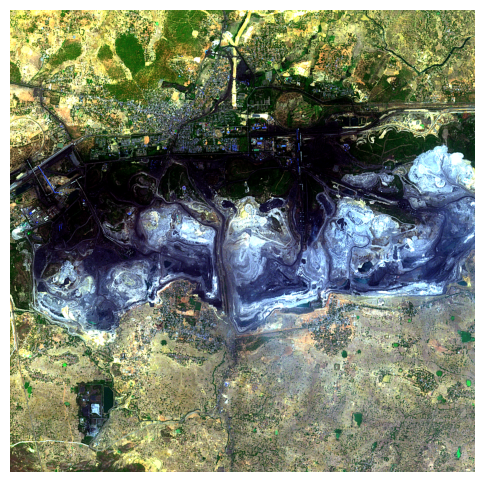

PNG saved: /content/drive/MyDrive/+Projects/Nudge-X/sites/GevraMine_rgb_2024-06-13.png

Processing: ndvi
0:00:00 Job 'j-260215165040465081602d350b7eea2b': send 'start'
0:00:15 Job 'j-260215165040465081602d350b7eea2b': created (progress 0%)
0:00:20 Job 'j-260215165040465081602d350b7eea2b': created (progress 0%)
0:00:27 Job 'j-260215165040465081602d350b7eea2b': created (progress 0%)
0:00:35 Job 'j-260215165040465081602d350b7eea2b': running (progress N/A)
0:00:45 Job 'j-260215165040465081602d350b7eea2b': running (progress N/A)
0:00:57 Job 'j-260215165040465081602d350b7eea2b': running (progress N/A)
0:01:13 Job 'j-260215165040465081602d350b7eea2b': running (progress N/A)
0:01:32 Job 'j-260215165040465081602d350b7eea2b': running (progress N/A)
0:01:56 Job 'j-260215165040465081602d350b7eea2b': running (progress N/A)
0:02:26 Job 'j-260215165040465081602d350b7eea2b': running (progress N/A)
0:03:04 Job 'j-260215165040465081602d350b7eea2b': running (progress N/A)
0:03:51 Job 'j-26021516504046508

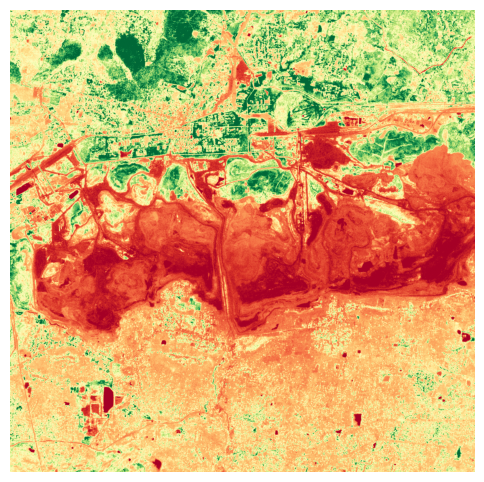

PNG saved: /content/drive/MyDrive/+Projects/Nudge-X/sites/GevraMine_ndvi_2024-06-13.png


In [36]:
#aspects = ["rgb", "ndvi", "urban_mining"]
aspects = ["rgb", "ndvi"]
#aspects = ["rgb"]
process_aspects(aspects, connection, bbox_s, city_s, start, end, satellite, max_cloud, datapathcities, small_png=True)